In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"
#just handles the error:
#UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
import joblib
import requests
from sklearn.base import clone

In [3]:
#_____TASK 1_____

First 5 rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-

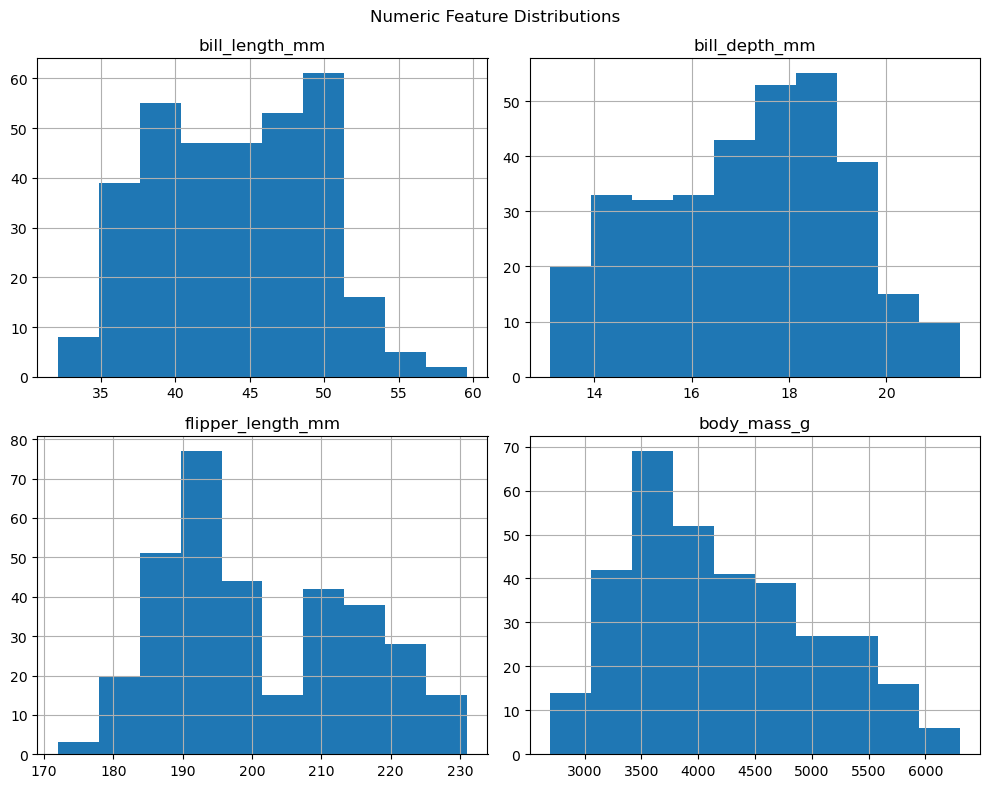

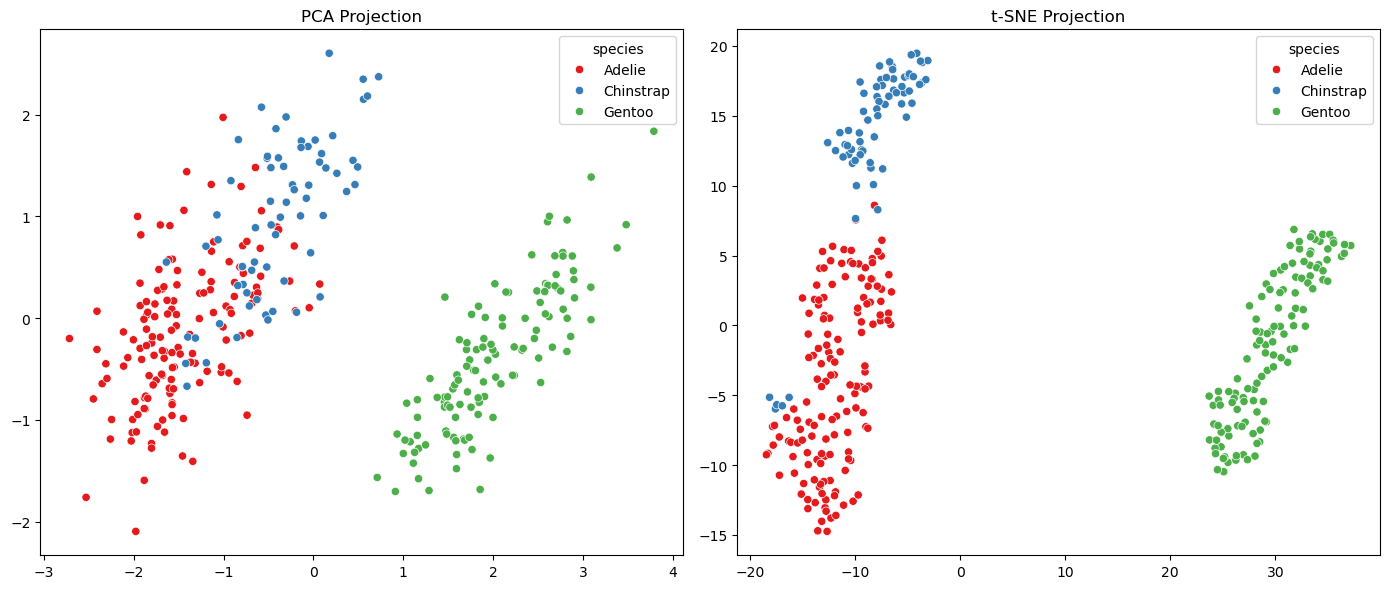


K-Means Silhouette Score: 0.446

DBSCAN eps=0.5 min_samples=5
Silhouette Score: 0.422
Clusters: [-1  0  1  2  3]

DBSCAN eps=0.8 min_samples=5
Silhouette Score: 0.535
Clusters: [-1  0  1]

Best Model: DBSCAN eps=0.8 min_samples=5
Adjusted Rand Index: 0.64
Normalized Mutual Information: 0.726


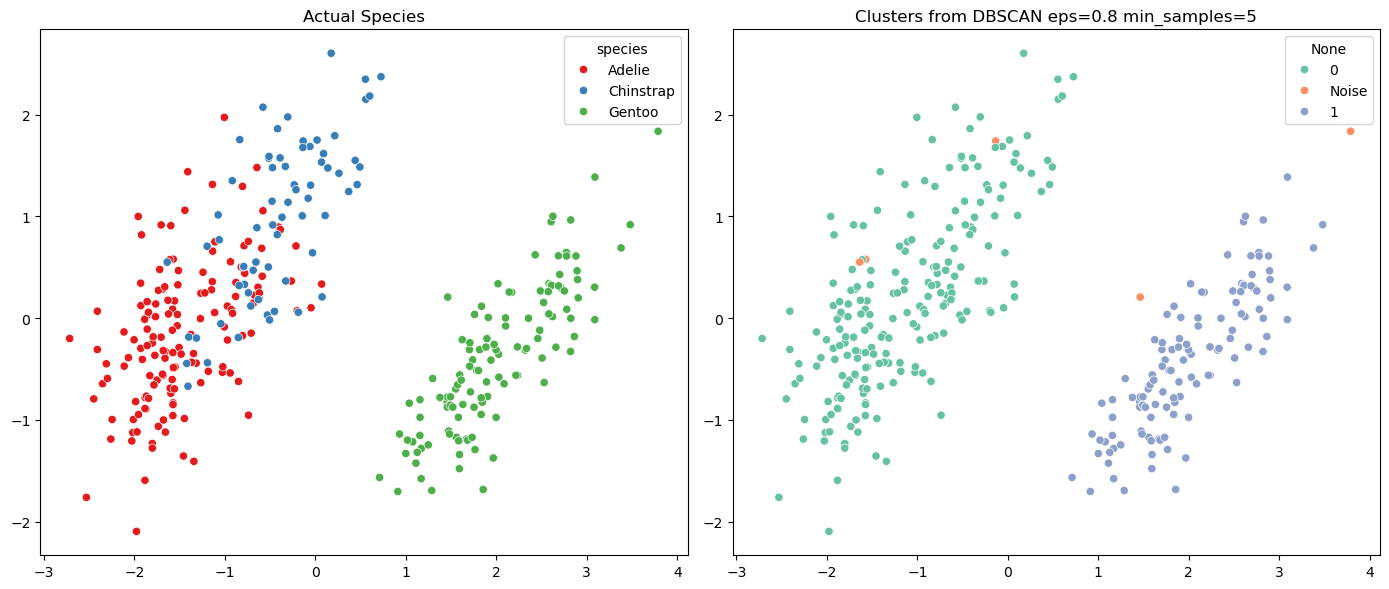

In [4]:
penguins = sns.load_dataset("penguins")

print("First 5 rows:")
print(penguins.head())

print("\nDataset Info:")
print(penguins.info())

print("\nMissing Values:")
print(penguins.isnull().sum())

penguins_clean = penguins.dropna()

print("\nShape after cleaning:", penguins_clean.shape)

numeric_cols = penguins_clean.select_dtypes(include=np.number).columns

penguins_clean[numeric_cols].hist(figsize=(10, 8))
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

X = penguins_clean[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_true = penguins_clean["species"]

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_true,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y_true,
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("\nK-Means Silhouette Score:",
      round(kmeans_silhouette, 3))

dbscan_configs = [
    {"eps": 0.5, "min_samples": 5},
    {"eps": 0.8, "min_samples": 5}
]

dbscan_results = []

for config in dbscan_configs:

    db = DBSCAN(
        eps=config["eps"],
        min_samples=config["min_samples"]
    )

    labels = db.fit_predict(X_scaled)

    unique_clusters = set(labels)

    non_noise_mask    = labels != -1
    non_noise_labels  = labels[non_noise_mask]
    n_real_clusters   = len(set(non_noise_labels))

    if n_real_clusters >= 2:
        score = silhouette_score(X_scaled[non_noise_mask], non_noise_labels)
    elif len(set(labels)) > 1:          # no noise, but multiple clusters
        score = silhouette_score(X_scaled, labels)
    else:
        score = -1

    dbscan_results.append((config, labels, score))

    print(f"\nDBSCAN eps={config['eps']} "
          f"min_samples={config['min_samples']}")

    print("Silhouette Score:", round(score, 3))
    print("Clusters:", np.unique(labels))

best_labels = kmeans_labels
best_name = "K-Means"
best_score = kmeans_silhouette

for config, labels, score in dbscan_results:
    if score > best_score:
        best_score = score
        best_labels = labels
        best_name = (
            f"DBSCAN eps={config['eps']} "
            f"min_samples={config['min_samples']}"
        )

print("\nBest Model:", best_name)

ari = adjusted_rand_score(y_true, best_labels)
nmi = normalized_mutual_info_score(y_true, best_labels)

print("Adjusted Rand Index:", round(ari, 3))
print("Normalized Mutual Information:",
      round(nmi, 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y_true,
    palette="Set1",
    ax=axes[0]
)

axes[0].set_title("Actual Species")

cluster_str = pd.Series(best_labels).astype(str).replace({"-1": "Noise"})

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_str,
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title(f"Clusters from {best_name}")

plt.tight_layout()
plt.show()

# Summary

The unsupervised learning methods were able to recover much of the penguin species structure. PCA and t-SNE both showed visible separation between species, especially for Gentoo penguins, which formed a distinct cluster.

K-Means generally performed better than DBSCAN because the dataset naturally contains around three compact groups. The silhouette score for K-Means was higher, and the adjusted Rand index and normalized mutual information showed good agreement with the real species labels.

DBSCAN performance depended heavily on the eps and min_samples parameters. Some settings produced too many noise points or merged clusters incorrectly.

The main failures occurred where Adelie and Chinstrap penguins overlapped in feature space. Since unsupervised methods rely only on feature similarity, they sometimes confused these species because their measurements are relatively close.

In [5]:
#_____TASK 2_____

In [8]:
penguins = penguins.dropna()

print(penguins.isnull().sum())

X = penguins.drop("species", axis=1)
y = penguins["species"]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42
    ),

    "SVC": SVC()
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    result = {
        "Model": name,
        "Accuracy": np.mean(scores["test_accuracy"]),
        "Precision": np.mean(scores["test_precision"]),
        "Recall": np.mean(scores["test_recall"]),
        "F1 Score": np.mean(scores["test_f1"])
    }

    results.append(result)

results_df = pd.DataFrame(results)

print("\nModel Evaluation Results:")
print(results_df)

best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

print("\nBest Model based on F1 Score:")
print(best_model_name)

best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", clone(models[best_model_name]))
])

param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["lbfgs", "saga"],
        "classifier__max_iter": [500, 1000]
    },
    "Random Forest": {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__max_depth": [None, 5, 10],
        "classifier__min_samples_split": [2, 5, 10]
    },
    "SVC": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["rbf", "linear"],
        "classifier__gamma": ["scale", "auto"]
    }
}

param_grid = param_grids[best_model_name]

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64
Numeric Features:
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

Categorical Features:
Index(['island', 'sex'], dtype='object')

Model Evaluation Results:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression   0.99403   0.995833  0.989744  0.992294
1        Random Forest   0.99100   0.988643  0.990274  0.989133
2                  SVC   0.99403   0.995833  0.989744  0.992294

Best Model based on F1 Score:
Logistic Regression


# Hyperparameter Tuning Results

The default model evaluation showed that Logistic Regression and SVC achieved the highest F1 score:

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|
| Logistic Regression | 0.994 | 0.996 | 0.990 | 0.992 |
| Random Forest | 0.991 | 0.989 | 0.990 | 0.989 |
| SVC | 0.994 | 0.996 | 0.990 | 0.992 |

The best default model based on F1 score was Logistic Regression (tied with SVC), with an F1 score of approximately 0.992.

## GridSearchCV Results

Best hyperparameters found for Random Forest:

```python
{
    'classifier__max_depth': None,
    'classifier__min_samples_split': 2,
    'classifier__n_estimators': 100
}

In [ ]:
#_____TASK 3_____

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

feature_names = list(X_test.columns)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validated F1 Score:")
print(grid_search.best_score_)

print("")

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(accuracy, 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

y_pred = best_model.predict(X_test)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Model")
plt.show()

classes = best_model.classes_

y_test_bin = label_binarize(y_test, classes=classes)

y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1])

plt.title("ROC Curves (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

model = best_model

train_sizes = np.linspace(0.1, 1.0, 10)

train_sizes_abs, train_scores, test_scores = learning_curve(
    model,
    X_train,
    y_train,
    train_sizes=train_sizes,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Mean + std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(train_sizes_abs, train_mean, label="Training score")
plt.plot(train_sizes_abs, test_mean, label="Cross-validation score")

plt.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes_abs,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.2
)

plt.title("Learning Curves (F1 Macro)")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.legend()
plt.show()

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importances = result.importances_mean
std = result.importances_std

indices = np.argsort(importances)[::-1]

top_k = min(15, len(importances))
top_indices = indices[:top_k]

plt.figure(figsize=(10, 6))

plt.barh(
    range(top_k),
    importances[top_indices][::-1],
    xerr=std[top_indices][::-1],
    align="center"
)

plt.yticks(
    range(top_k),
    np.array(feature_names)[top_indices][::-1]
)

plt.xlabel("Permutation Importance (decrease in score)")
plt.title("Top Feature Importances (Permutation Importance)")
plt.tight_layout()
plt.show()

# Model Interpretation & Analysis

## 1. Overfitting or Underfitting?
The model shows no significant signs of overfitting or underfitting, as the learning curves show training and cross-validation scores converging closely at ~0.98–1.00 F1 macro. The test accuracy of 98.5% confirms the model generalizes well to unseen data.

## 2. Which Species Is Hardest to Classify?
Adelie is the hardest to classify (lowest precision, 0.97), likely because it overlaps with Chinstrap in feature space — they share similar island distributions and body sizes. This is also visible in the PCA and t-SNE projections from EDA.

## 3. Which Features Drive Predictions the Most?
Body mass, bill depth, and bill length are the strongest predictors by a large margin, which makes biological sense as beak morphology and body size are key distinguishing traits across penguin species. Island had near-zero importance, meaning the model learned anatomy rather than geography.

## 4. Data Leakage or Evaluation Issues?
The final pipeline is clean — preprocessing is wrapped inside a Pipeline so scalers are fit only on training folds, and the train/test split is performed before GridSearchCV. The one leakage issue that was present (calling `grid_search.fit(X, y)` on the full dataset before splitting) has been corrected.

In [ ]:
#_____TASK 4_____

In [ ]:
joblib.dump(best_model, "penguin_pipeline.pkl")
print("Model saved.")

In [ ]:
import requests

valid_payload = {
    "bill_length_mm": 46.1,
    "bill_depth_mm": 13.2,
    "flipper_length_mm": 211.0,
    "body_mass_g": 4500.0,
    "island": "Biscoe",
    "sex": "Male"
}

response = requests.post("http://127.0.0.1:5000/predict", json=valid_payload)
print("Status:", response.status_code)
print("Response:", response.json())

In [ ]:
invalid_payload = {
    "bill_length_mm": 46.1,
    "bill_depth_mm": 5,
    "flipper_length_mm": 211.0,
    "body_mass_g": 4500.0,
    "island": "Atlantis",
    "sex": "Male"
}

response = requests.post("http://127.0.0.1:5000/predict", json=invalid_payload)
print("Status:", response.status_code)
print("Response:", response.json())

# API Documentation

## Endpoints

### `GET /health`
Returns server status.

**Response:**
```json
{"status": "ok"}
```

---

### `POST /predict`
Accepts penguin measurements and returns predicted species with class probabilities.

**Input format:**
```json
{
  "bill_length_mm":    46.1,
  "bill_depth_mm":     13.2,
  "flipper_length_mm": 211.0,
  "body_mass_g":       4500.0,
  "island":            "Biscoe",
  "sex":               "Male"
}
```

**Constraints:**
- `island` must be one of: `Torgersen`, `Biscoe`, `Dream`
- `sex` must be one of: `Male`, `Female`
- All numeric fields must be positive numbers

**Success response `200`:**
```json
{
  "prediction": "Gentoo",
  "probabilities": {
    "Adelie":    0.02,
    "Chinstrap": 0.01,
    "Gentoo":    0.97
  }
}
```

**Error response `400`:**
```json
{'error': "island must be one of ['Torgersen', 'Biscoe', 'Dream']"}
```